# Import Libraries

In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot

from PIL import Image
import numpy as np

# Load MNIST Dataset

In [ ]:
dataset = load_digits()

X = dataset.data
y = dataset.target

# Show Some Samples of The Dataset

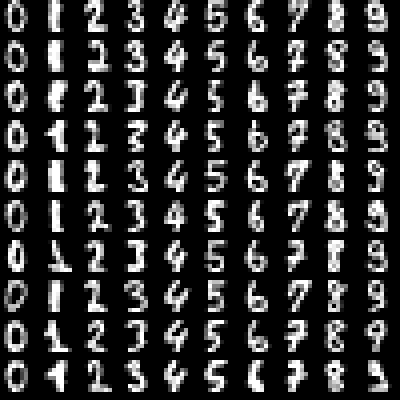

In [ ]:
im = Image.new('L', (100, 100))
data = np.array(np.round(dataset.data / 16 * 255), dtype='uint8')

for i in range(10):
    idxs = np.random.choice((dataset.target == i).nonzero()[0], size=10, replace=False)
    for j, a in enumerate(data[idxs]):
        im_ = Image.fromarray(a.reshape(8, 8), 'L')
        im.paste(im_, (10*i, 10*j))

im.resize((400, 400), resample=Image.BOX)

# Test Prediction Performance Based On Percent of Variance

In [ ]:
percents = []
n_comps = []
scores = []

for percent in range(1, 100):
    pca = PCA(percent / 100)
    X_pca = pca.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    percents.append(percent)
    n_comps.append(pca.n_components_)
    scores.append(score)

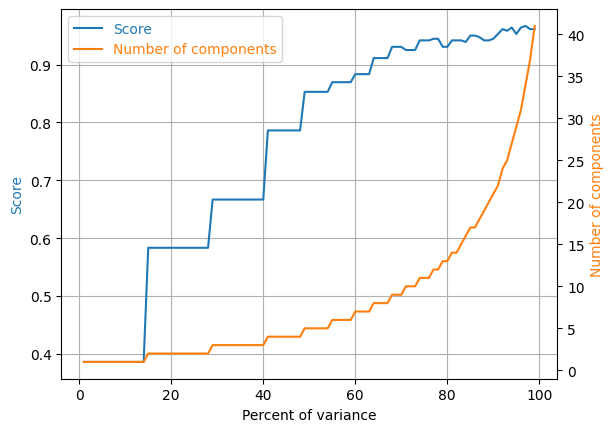

In [ ]:
host = host_subplot(111)
par = host.twinx()

host.set_xlabel("Percent of variance")
host.set_ylabel("Score")
par.set_ylabel("Number of components")

p1, = host.plot(percents, scores, label="Score")
p2, = par.plot(percents, n_comps, label="Number of components")

host.legend(labelcolor="linecolor")

host.yaxis.get_label().set_color(p1.get_color())
par.yaxis.get_label().set_color(p2.get_color())

plt.grid()
plt.show()

# Test Prediction Performance Based On Number of Components

In [ ]:
n_comps = []
scores = []

for n_comp in range(1, 64+1):
    pca = PCA(n_comp)
    X_pca = pca.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    n_comps.append(pca.n_components_)
    scores.append(score)

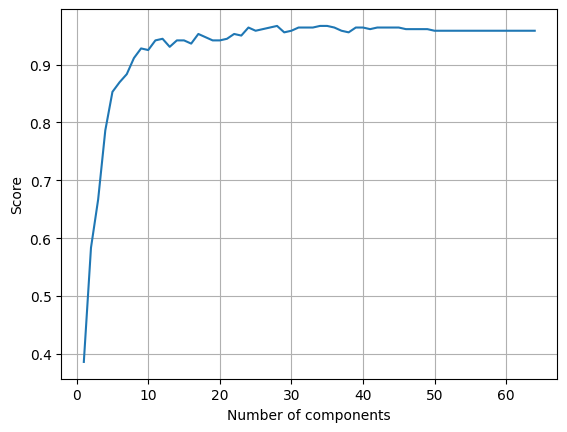

In [ ]:
fig, ax = plt.subplots()
ax.plot(n_comps, scores)

ax.set(xlabel='Number of components', ylabel='Score')
ax.grid()
plt.show()

# Test Prediction Performance Based On Some SVD Algorithms

### svd_solver='full'

In [ ]:
n_comps = []
scores_full = []

for n_comp in range(1, 64+1):
    pca = PCA(n_comp, svd_solver='full')
    X_pca = pca.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    n_comps.append(pca.n_components_)
    scores_full.append(score)

### svd_solver='randomized'

In [ ]:
n_comps = []
scores_rand = []

for n_comp in range(1, 64+1):
    pca = PCA(n_comp, svd_solver='randomized')
    X_pca = pca.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    n_comps.append(pca.n_components_)
    scores_rand.append(score)

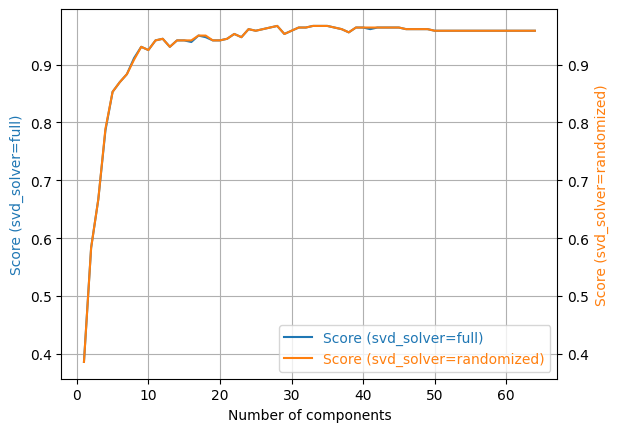

In [ ]:
host = host_subplot(111)
par = host.twinx()

host.set_xlabel("Number of components")
host.set_ylabel("Score (svd_solver=full)")
par.set_ylabel("Score (svd_solver=randomized)")

p1, = host.plot(n_comps, scores_full, label="Score (svd_solver=full)")
p2, = par.plot(n_comps, scores_rand, label="Score (svd_solver=randomized)")

host.legend(labelcolor="linecolor")

host.yaxis.get_label().set_color(p1.get_color())
par.yaxis.get_label().set_color(p2.get_color())

plt.grid()
plt.show()

# Test Prediction Performance Based On Number of Oversamples

In [ ]:
n_overs = []
scores = []

for n_over in range(1, 21):
    pca = PCA(1, svd_solver='randomized', n_oversamples=n_over, random_state=10)
    X_pca = pca.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    n_overs.append(n_over)
    scores.append(score)

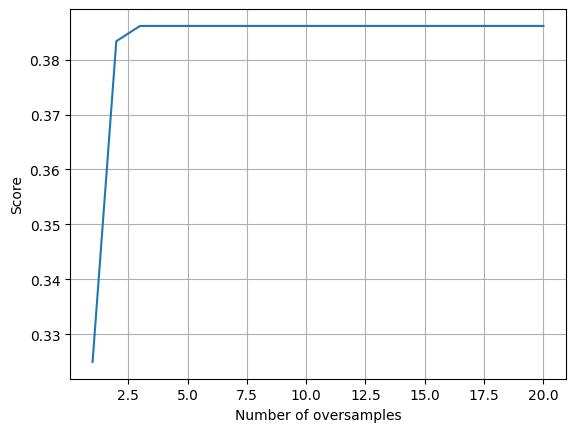

In [ ]:
fig, ax = plt.subplots()
ax.plot(n_overs, scores)

ax.set(xlabel='Number of oversamples', ylabel='Score')
ax.grid()
plt.show()